## Quantum Fourier Transform (QFT)

The QFT is the quantum version of the classical DFT — it transforms basis states
into phase-encoded superpositions.

This notebook includes:

1. **1-qubit** — just a Hadamard
2. **2-qubit** — H + one controlled-phase gate
3. **n-qubit QFT** — general case with the full H → R_k gate pattern
4. **n-qubit Inverse QFT** — swaps + negative phase gates to reverse the transform

Each case shows the circuit, Bloch sphere, histogram, and statevector.

In [69]:
import matplotlib.pyplot as plt
import numpy as np
from qiskit import QuantumCircuit,transpile
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Statevector
from qiskit.visualization import plot_bloch_multivector, plot_histogram, array_to_latex

In [71]:
def histogramRep(circuit: QuantumCircuit, shots: int = 1024):
   
    qch = circuit.copy()            
    qch.measure_all()                 

    sim = AerSimulator()
    tqc = transpile(qch, sim)
    result = sim.run(tqc, shots=shots).result()

    counts = result.get_counts()
    fig = plot_histogram(counts)      
    plt.show()
    return fig

In [73]:
def blochSphere(circuit: QuantumCircuit):
   
    qc = circuit.copy()               
    qc.save_statevector()            

    sim = AerSimulator(method='statevector')
    tqc = transpile(qc, sim)
    result = sim.run(tqc).result()

    state = result.get_statevector(tqc)    
    fig = plot_bloch_multivector(state)   
    plt.show()
    return fig

enter the value ( 0 or 1): 0


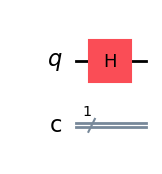

In [77]:
#for single qbit
qft = QuantumCircuit(1,1)
a = input("enter the value ( 0 or 1):")
if a=='1':
    qft.x(0)
qft.h(0)

state = Statevector.from_instruction(qft)

qft.draw('mpl')

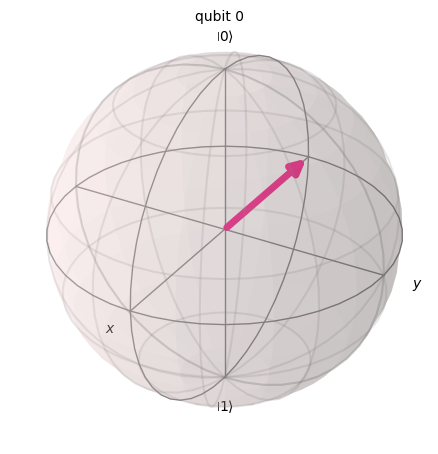

In [43]:
blochSphere(qft)

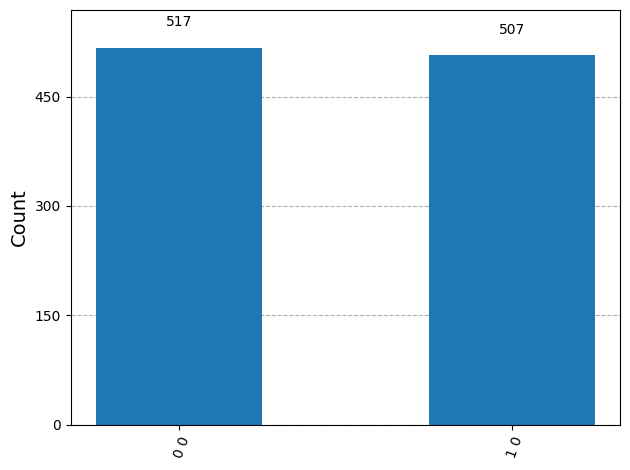

In [45]:
histogramRep(qft)

In [79]:
display(array_to_latex(state.data, prefix="j1 ="))
#state = Statevector(qft)
state.draw("latex")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

In [47]:
#for 2 qbit

enter value for qbits from 0 to 4 in binary: 01


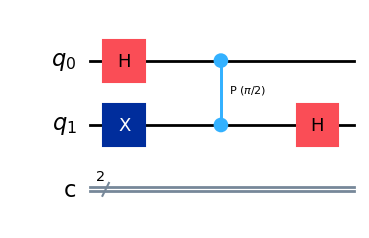

In [87]:
qft2 = QuantumCircuit(2,2)
b = input("enter value for qbits from 0 to 4 in binary:")
if b[0]=='1':
    qft2.x(0)
if b[1]=='1':
    qft2.x(1)

qft2.h(0)
qft2.cp(np.pi/2,1,0)
qft2.h(1)

state = Statevector.from_instruction(qft2)
qft2.draw('mpl')

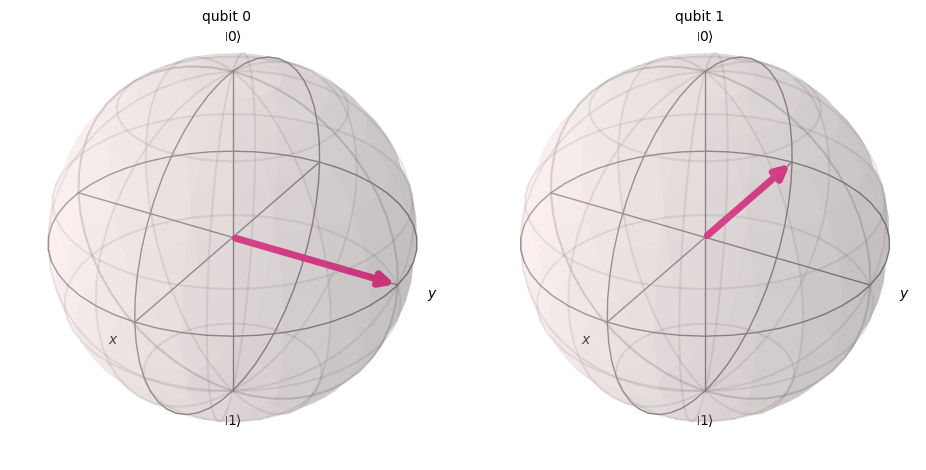

In [83]:
blochSphere(qft2)

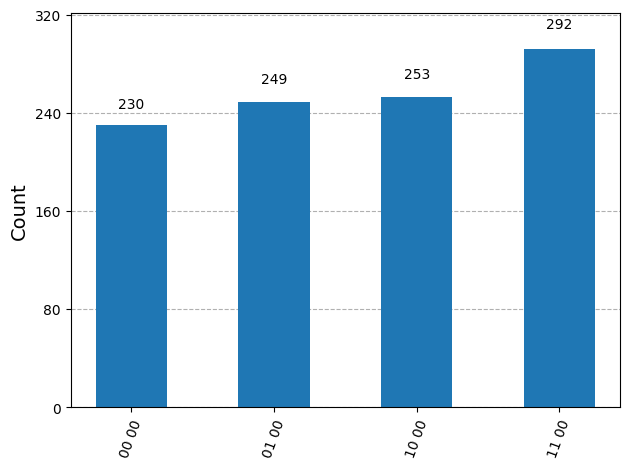

In [85]:
histogramRep(qft2)

In [89]:
display(array_to_latex(state.data, prefix="j1 ="))
#state = Statevector(qft)
state.draw("latex")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

enter the no of qbits (1 or 2): 2
enter function value: 10


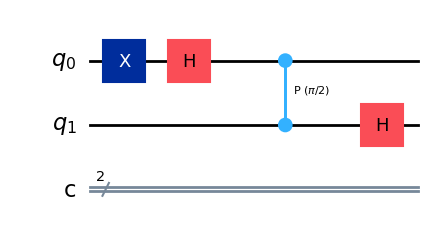

In [141]:
#2 qbit general case
y = int(input("enter the no of qbits (1 or 2):"))
qft_gn2 = QuantumCircuit (y,y)
z = input("enter function value:")

for i in range(y):
    if z[i]=='1':
        qft_gn2.x(i)
for j in range(y):
    if j>0:
        qft_gn2.cp(np.pi/2,1,0)
    qft_gn2.h(j)
state = Statevector.from_instruction(qft_gn2)
qft_gn2.draw('mpl')

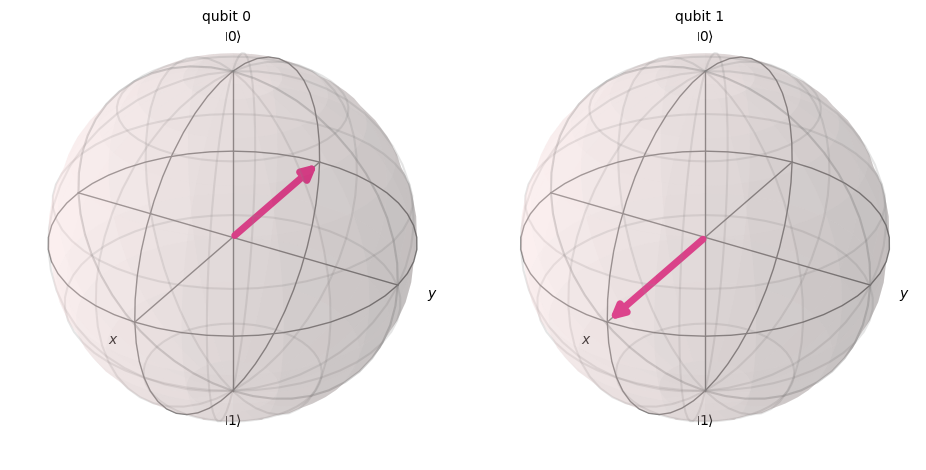

In [143]:
blochSphere(qft_gn2)

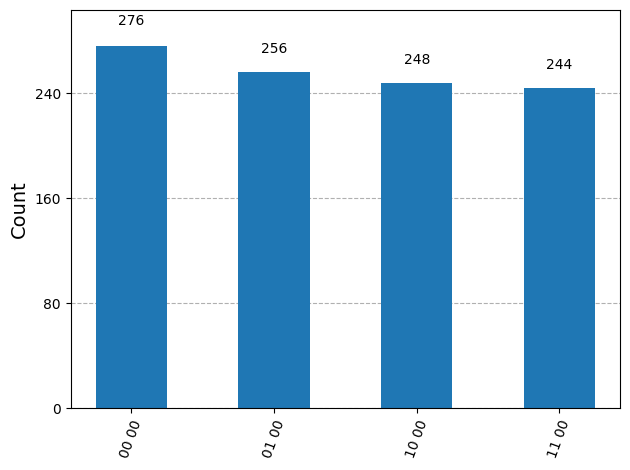

In [145]:
histogramRep(qft_gn2)

In [147]:
display(array_to_latex(state.data, prefix="j1 ="))
#state = Statevector(qft)
state.draw("latex")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Enter the no of qbit: 4
Enter the Function in binary: 1101


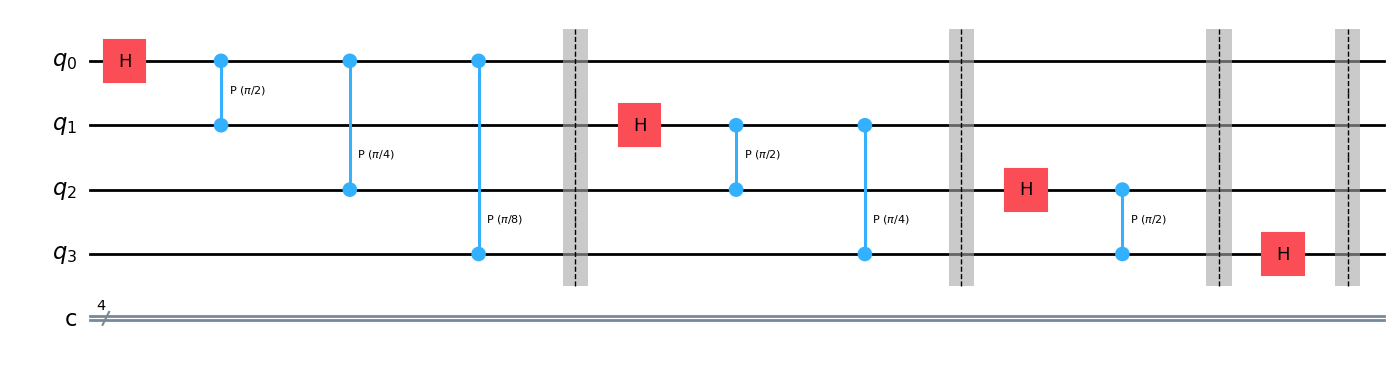

In [169]:
n = int(input("Enter the no of qbit:"))
x = input("Enter the Function in binary:")
qft_gn = QuantumCircuit(n,n)
for i in range(n):
    if x[i]==1:
        qft_gn.x(i)

for j in range(n):
    qft_gn.h(j)
    for k in range(j+1,n):
        qft_gn.cp(np.pi/(2**(k-j)),k,j)
    qft_gn.barrier()
    
state = Statevector.from_instruction(qft_gn)
qft_gn.draw('mpl')



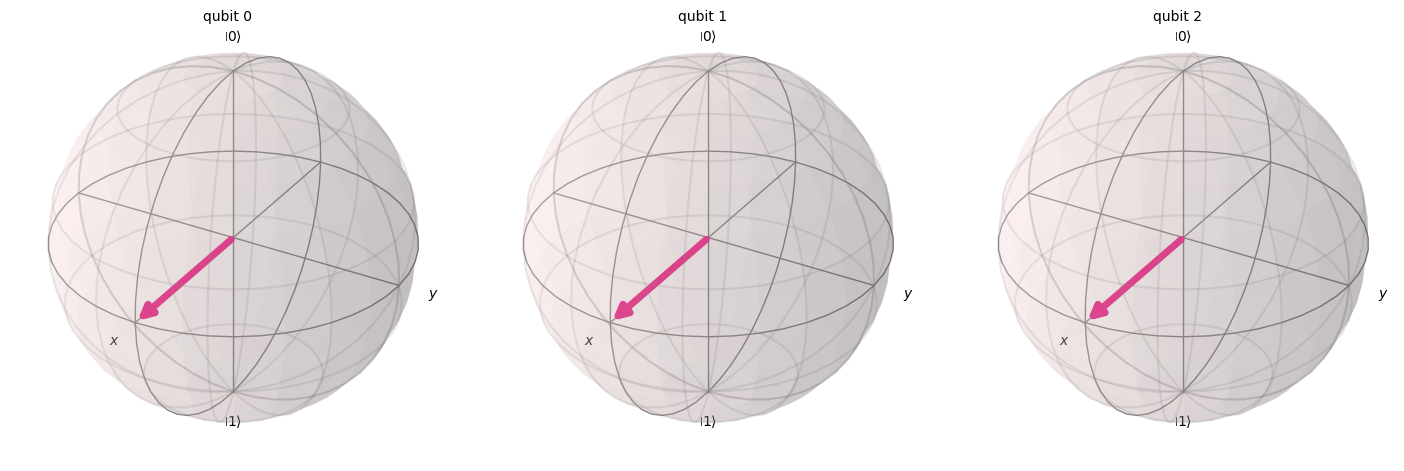

In [155]:
blochSphere(qft_gn)

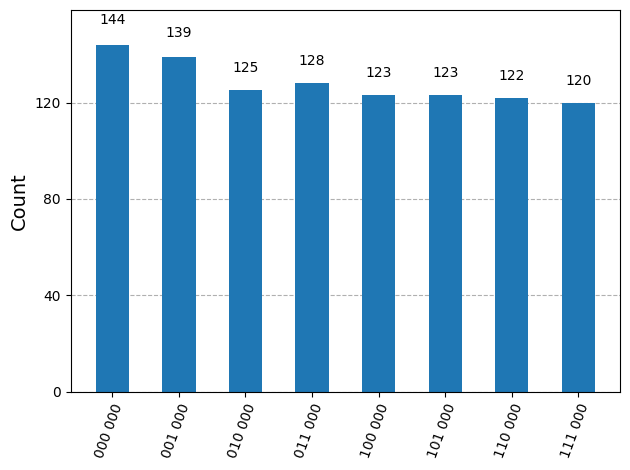

In [157]:
histogramRep(qft_gn)

In [167]:
display(array_to_latex(state.data, prefix="j1 ="))
state.draw("latex")

<IPython.core.display.Latex object>

<IPython.core.display.Latex object>

Enter the no of qbit: 4
Enter the Function in binary: 1101


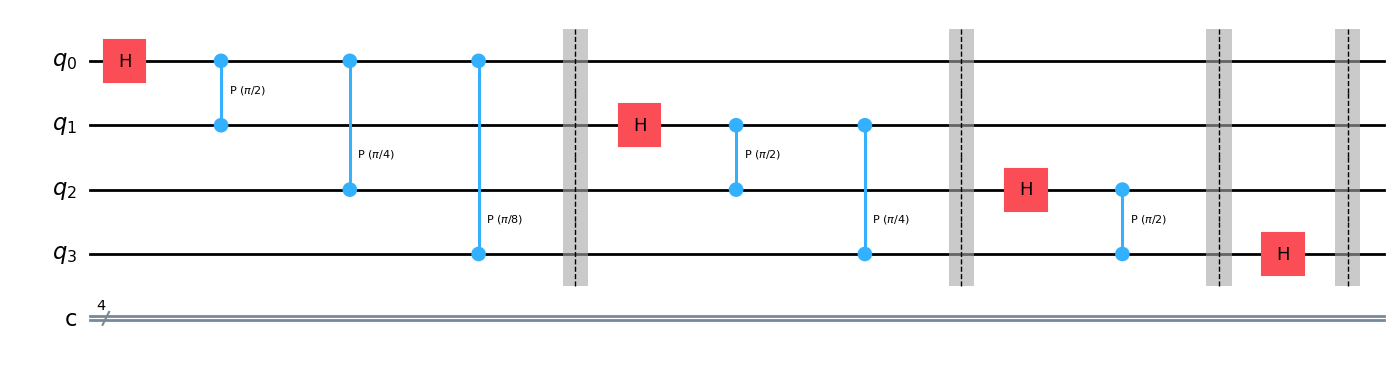

In [177]:
n = int(input("Enter the no of qbit:"))
x = input("Enter the Function in binary:")
qft_gn = QuantumCircuit(n,n)
for i in range(n):
    if x[i]==1:
        qft_gn.x(i)

for j in range(n):
    qft_gn.h(j)
    for k in range(j+1,n):
        
        qft_gn.cp(np.pi/(2**(k-j)),k,j)
    qft_gn.barrier()
    
    
state = Statevector.from_instruction(qft_gn)
qft_gn.draw('mpl')


Enter the no of qubit:  4
Enter the Function in binary:  1101


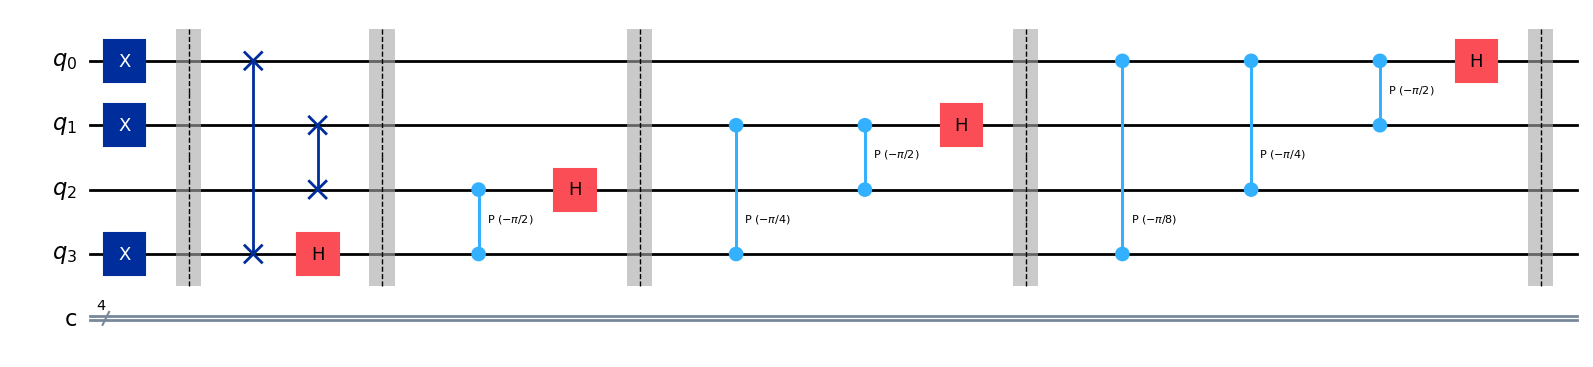

In [179]:
import numpy as np
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

n = int(input("Enter the no of qubit: "))
x = input("Enter the Function in binary: ")

# Initialize circuit
iqft_gn = QuantumCircuit(n, n)

# Prepare initial state based on binary input
for i in range(n):
    if x[i] == '1':
        iqft_gn.x(i)
iqft_gn.barrier()

# --- Inverse QFT Logic ---

# 1. Reverse the order of the qubits (Swaps)
for i in range(n // 2):
    iqft_gn.swap(i, n - i - 1)

# 2. Iterate backwards through the qubits
for j in range(n - 1, -1, -1):
    # Apply negative controlled phase gates in reverse order
    for k in range(n - 1, j, -1):
        iqft_gn.cp(-np.pi / (2**(k - j)), k, j)
    
    # Apply Hadamard
    iqft_gn.h(j)
    iqft_gn.barrier()

# Calculate statevector
state = Statevector.from_instruction(iqft_gn)

# Draw circuit
iqft_gn.draw('mpl')
